<a href="https://colab.research.google.com/github/RuneDaeg/my-webapp22/blob/main/%EC%A0%84%EA%B3%B5%EC%8B%AC%ED%99%94_lab(%EC%97%AC%EA%B4%91%EC%9E%AC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**0. 라이브러리 불러오기**
- import: python의 라이브러리를 불러옴
- import ~ as @: ~를 불러올 때 @로 부르겠다고 선언
- from ~ import @ as #: ~에서 @를 불러오는데, 그걸 #로 부르겠다고 선언

In [ ]:
import pandas as pd # 표 데이터를 다루는 분석 도구
import numpy as np # 복잡한 수학 연산, 미분, 배열 계산 등 수학 도구
import matplotlib.pyplot as plt # 예쁜 그래프를 그려주는 도구
from scipy.stats import linregress # scipy : 최적의 상수를 찾아주는 도구
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score as rs

**1. 등속 운동 분석하기**

𝓍(t)=𝓍(0) + 𝓋t \
𝓋(t)=𝓋 → 시간에 따른 속력이 일정!

   t  x
0  0  0
1  1  2
2  2  4
3  3  6
4  4  8
Fitted function is x = 2.00 * t + 0.00
Parameter - velocity: 2.00 m/s, initial position: 0.00


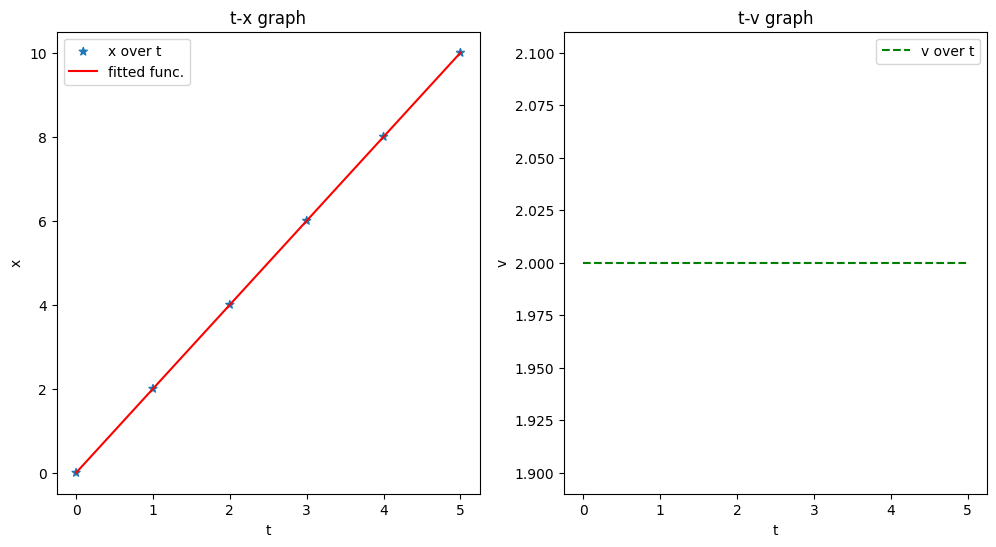

In [ ]:
#1. 데이터 불러오기
file_path = '/content/uni.txt' # data file 경로
data = pd.read_csv(file_path, sep='\t') # data file을 읽어와서 탭(tab, \t)으로 구분된 텍스트 파일 읽어옴
print(data.head()) # 데이터가 잘 깨지지 않고 들어왔는지 상위 5개 행만 맛보기로 출력

#2. 변수 지정
t = data['t']
x = data['x']
    # print(t[1], x[1])

#3. 그래프 fitting -> 매개변수 찾기
def x_func(t, v, x0): #def x_func(독립변수, 파라미터0=A, 파라미터1=B, ...) -> At+B
  return v * t + x0 # x(t)=vt+x0
  # params[0]=v, params[1]=x0
fitted_func_str = "x = {:.2f} * t + {:.2f}".format(params[0], params[1])
print("Fitted function is", fitted_func_str)
print("Parameter - velocity: {:.2f} m/s, initial position: {:.2f}".format(params[0], params[1]))

v = np.gradient(x, t)

#4. fitting
params, covariance = curve_fit(x_func, t, x)
  #print("parameter 0 is ", params[0])

#5. 그래프를 그려보자
plt.figure(figsize=(12, 6)) # 12 * 6의 도화지를 깔겠다.

  #1. t-x 그래프
plt.subplot(1,2,1) # 1행 2열 중 첫 칸에 그래프를 그리겠다.
plt.title("t-x graph") # 그래프의 제목
plt.scatter(t, x, marker='*', linestyle="", label='x over t')
plt.plot(t, x_func(t, *params), color='red', label='fitted func.')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()

  #2. t-v 그래프
plt.subplot(1,2,2)
plt.title("t-v graph") # 그래프의 제목
plt.plot(t, v, color='green', linestyle="--", label='v over t')
plt.xlabel('t')
plt.ylabel('v')
plt.legend()

**2. 자유 낙하 운동 분석하기**

𝓍(t) = 𝓍(0) + 𝓋(0)t + ½gt\^2 \
𝓋(t) = 𝓋(0) + gt → 시간에 따른 속력 변화가 일정! \
𝒶(t) = g

     t      x
0  0.0  0.000
1  0.1  0.049
2  0.2  0.196
3  0.3  0.441
4  0.4  0.784
0.1 0.049
Fitted func: x = 0.5 * 9.80 * t^2 + 0.00 * t + 0.00
중력 가속도 :  9.799999940844543


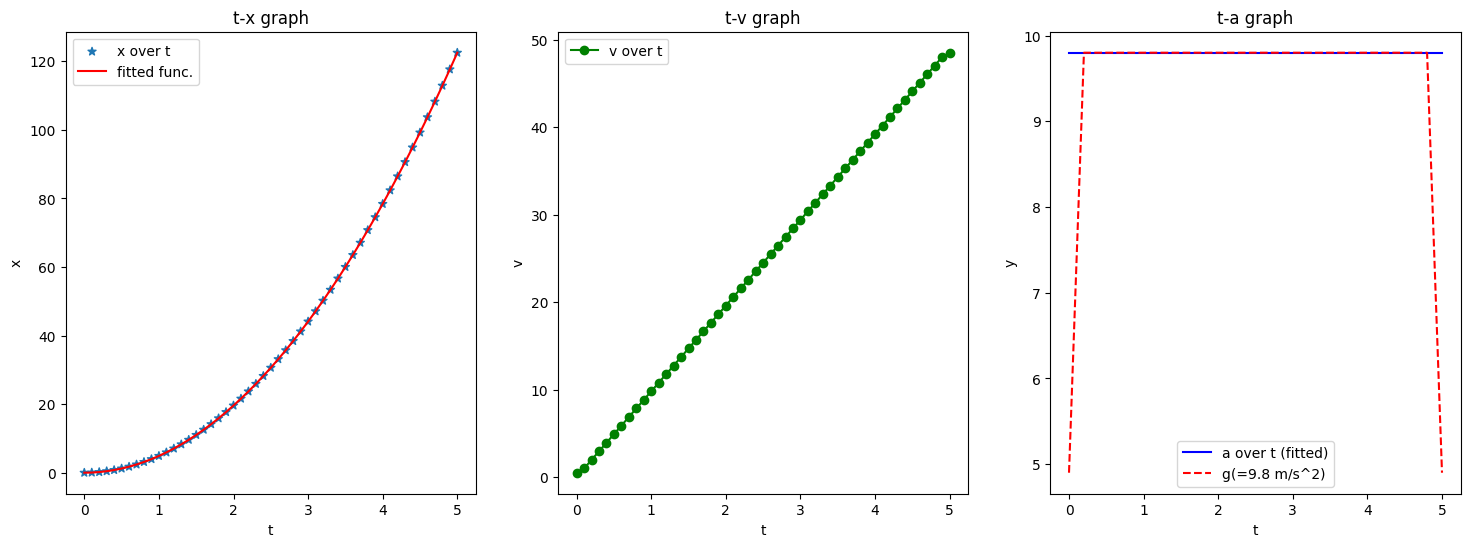

In [ ]:
#1. 데이터 불러오기
file_path = '/content/ffm.txt' # data file 경로
data = pd.read_csv(file_path, sep='\t') # data file을 읽어와서 탭(tab, \t)으로 구분된 텍스트 파일 읽어옴
print(data.head()) # 데이터가 잘 깨지지 않고 들어왔는지 상위 5개 행만 맛보기로 출력

#2. 변수 지정
t = data['t']
x = data['x'] # 낙하한 거리
print(t[1], x[1])

#3. 그래프 fitting -> 매개변수 찾기
def x_func(t, g, v0): #def x_func(독립변수, 파라미터0=A, 파라미터1=B, ...)
  return 0.5 * g * t * t + v0 * t + x[0]
  # params[0]=g, params[1]=v0

params, covariance = curve_fit(x_func, t, x)
fitted_func = "Fitted func: x = 0.5 * {:.2f} * t^2 + {:.2f} * t + {:.2f}".format(params[0], params[1], x[0])
print(fitted_func)
print("중력 가속도 : ", params[0])

#4. 속도, 가속도를 계산
v = np.gradient(x, t) # 실제값 -> v 계산
a = [params[0]] * len(t) # 찾아진 파라미터
a_c = np.gradient(v, t, edge_order=1) # 계산해낸 v값을 한번 더 미분 -> 가속도

#5. 그래프를 그려보자
plt.figure(figsize=(18, 6))

##1. t-x 그래프
plt.subplot(1,3,1) # 1행 3열 중 첫 칸에 그래프를 그리겠다.
plt.title("t-x graph") # 그래프의 제목
plt.scatter(t, x, marker='*', linestyle="", label='x over t')
plt.plot(t, x_func(t, *params), color='red', label='fitted func.')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()

##2. t-v 그래프
plt.subplot(1,3,2)
plt.title("t-v graph")
plt.plot(t, v, marker='o', color='green', label='v over t')
plt.xlabel('t')
plt.ylabel('v')
plt.legend()

##3. t-a 그래프
plt.subplot(1,3,3)
plt.title("t-a graph")
plt.plot(t, a, color='blue', label='a over t (fitted)')
plt.plot(t, a_c, color='red', linestyle='--', label='a over t')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()

**3. 포물선 운동 분석(공기저항 유무)**
포물선 운동은 공기 저항이 없는 경우 아래 방향(-y 방향)으로는 일정한 중력을 받고, 수평 방향으로는 힘을 받지 않는다.

각도 ϴ를 가지고 초기 속도 𝓋(0)으로 쏘아 올린 공의 경우 각 방향으로의 운동 방정식은 다음과 같다.

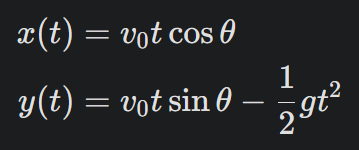


만일, 공기 저항을 고려한 경우 모든 방향으로의 이동 거리가 지수함수적으로 줄어들게 되는데, 이때 거리는 다음과 같다. (증명 생략!)

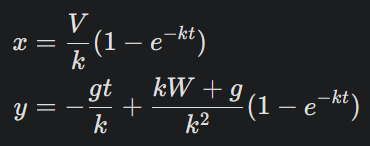

In [ ]:
# Data file path
file_path1 = '/content/trm.txt'
file_path2 = '/content/restrm.txt'

# Data file load
data1 = pd.read_csv(file_path1, sep=r'\s+', on_bad_lines='warn')
data2 = pd.read_csv(file_path2, sep='\t')

# Data check
print(data1.head())
print(data2.head())

# Variable assignment
t1 = data1['t']
x1 = data1['x']
y1 = data1['y']

t2 = data2['t']
x2 = data2['x']
y2 = data2['y']

g = 9.81 # [m/s^2]

# Variable Check
print(t1[1], x1[1], y1[1])
print(t2[1], x2[1], y2[1])

# Graph Fitting
def x_func(t, x0, v0x):
  return x0 + v0x * t

def y_func(t, y0, v0y):
  return y0 + v0y * t - 0.5 * g * t**2

def res_x_func(t, x0, v0x, damp):
  return x0 + v0x/damp * (1 - np.exp(-damp * t))

def res_y_func(t, y0, v0y, damp):
  return y0 - g/damp * t + (damp * v0y + g)/damp**2 * (1 - np.exp(-damp * t))

# Run Fitting
params_x1, covariance = curve_fit(x_func, t1, x1)
params_y1, covariance = curve_fit(y_func, t1, y1)

params_x2, covariance = curve_fit(res_x_func, t2, x2)
params_y2, covariance = curve_fit(res_y_func, t2, y2)

# Print Fitted function - x
fitted_function_str1 = "{:.2f} + {:.2f} * t".format(params_x1[0], params_x1[1])
print("Fitted x-t function without air resistance:", fitted_function_str1)
print("Fitted parameters:", params_x1)

fitted_function_str2 = "{:.2f} + {:.2f}/{:.2f} * (1 - exp(-{:.2f}*t)".format(params_x2[0], params_x2[1], params_x2[2], params_x2[2])
print("Fitted x-t function with air resistance:", fitted_function_str2)
print("Fitted parameters:", params_x2)

# Print Fitted function - y
fitted_function_str1 = "{:.2f} + {:.2f} * t - 0.5 * g * t^2".format(params_y1[0], params_y1[1])
print("Fitted y-t function without air resistance:", fitted_function_str1)
print("Fitted parameters:", params_y1)

fitted_function_str2 = "{:.2f} - g/{:.2f} * t + ({:.2f} * {:.2f} + g)/{:.2f}^2 * (1 - exp(-{:.2f} * t))".format(params_y2[0], params_y2[2], params_y2[1], params_y2[2], params_y2[2], params_y2[2])
print("Fitted y-t function with air resistance:", fitted_function_str2)
print("Fitted parameters:", params_y2)

# Root Mean Square
def rms(data):
    mean = np.mean(data)
    squared_diff = np.sum((data - mean) ** 2)
    rms = np.sqrt(squared_diff / len(data))
    return rms

rms_x1 = rms(x1)
rms_y1 = rms(y1)
rms_x2 = rms(x2)
rms_y2 = rms(y2)

print("RMS for x1:", rms_x1)
print("RMS for y1:", rms_y1)
print("RMS for x2:", rms_x2)
print("RMS for y2:", rms_y2)

# 그래서 실제로는 다음과 같은 코드를 이용해야 함.
def calculate_rmse(actual, predicted):
	return np.sqrt(np.mean((actual - predicted) ** 2))

real_rmse_x = calculate_rmse(x1, x_func(t1, *params_x1))
real_rmse_y = calculate_rmse(y1, y_func(t1, *params_y1))
print("진짜 x1의 오차 (RMSE):", real_rmse_x)
print("진짜 y1의 오차 (RMSE):", real_rmse_y)

# Plotting without air resistance
plt.figure(figsize=(12,5))

## 1. x over time
plt.subplot(1,3,1)
plt.title('x over time')
plt.scatter(t1, x1, marker='o', linestyle='', label='position over time')
plt.plot(t1, x_func(t1, *params_x1), color='red', label='Fitted curve')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(loc='upper right')

## 2. y over time
plt.subplot(1,3,2)
plt.title('y over time')
plt.scatter(t1, y1, marker='o', linestyle='', label='position over time')
plt.axhline(y=0, color='green', linestyle='-', label='ground(h=0)')
plt.plot(t1, y_func(t1, *params_y1), color='red', label='Fitted curve')
plt.xlabel('t')
plt.ylabel('y')
plt.legend(loc='upper right')

## 3. projectile motion without air resistance
plt.subplot(1,3,3)
plt.title('projectile motion without air resistance')
plt.scatter(x1, y1, marker='o', linestyle='', label="xy")
plt.axhline(y=0, color='green', linestyle='-', label='ground(h=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


# Plotting with air resistance
plt.figure(figsize=(12,5))

## 1. x over time
plt.subplot(1,3,1)
plt.title('x over time')
plt.scatter(t2, x2, marker='o', linestyle='', label='position over time')
plt.plot(t2, res_x_func(t2, *params_x2), color='red', label='Fitted curve')
plt.xlabel('t')
plt.ylabel('x')
plt.legend(loc='upper right')

## 2. y over time
plt.subplot(1,3,2)
plt.title('y over time')
plt.scatter(t2, y2, marker='o', linestyle='', label='position over time')
plt.axhline(y=0, color='green', linestyle='-', label='ground(h=0)')
plt.plot(t2, res_y_func(t2, *params_y2), color='red', label='Fitted curve')
plt.xlabel('t')
plt.ylabel('y')
plt.legend(loc='upper right')

## 3. projectile motion without air resistance
plt.subplot(1,3,3)
plt.title('projectile motion with air resistance')
plt.scatter(x1, y1, marker='o', linestyle='', label="without air resistance")
plt.scatter(x2, y2, marker='o', linestyle='', label="with air resistance (k={:.2f})".format(params_y2[2]))
plt.axhline(y=0, color='green', linestyle='-', label='ground(h=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

**4. 진자 운동 분석(공기 저항 x)**

𝓍 = 𝒜sin(𝜔t+ϕ)+x(0) ,
𝓎 = ℬcos(𝜔t+ψ)+y(0)
으로 계산해볼 수 있다.

          t         x         y
0  2.366667 -0.063033  0.010427
1  2.400000 -0.063507  0.010900
2  2.433333 -0.058768  0.009479
3  2.466667 -0.054502  0.007583
4  2.500000 -0.047867  0.005687
Fitted function (x): 0.06 * sin(2 * pi * 0.85 * t + 4.68) + 0.00
Fitted parameters (x) [amp, freq, phase, pos_i]: [6.28754508e-02 8.46992925e-01 4.67783473e+00 4.89463492e-04]
Fitted function (y): 0.00 * cos(2 * pi * 1.70 * t + -0.16) + 0.00
Fitted parameters (y) [amp, freq, phase, pos_i]: [ 0.00480972  1.6964704  -0.1609829   0.00445244]
RMSE for x: 0.00104
RMSE for y: 0.00049


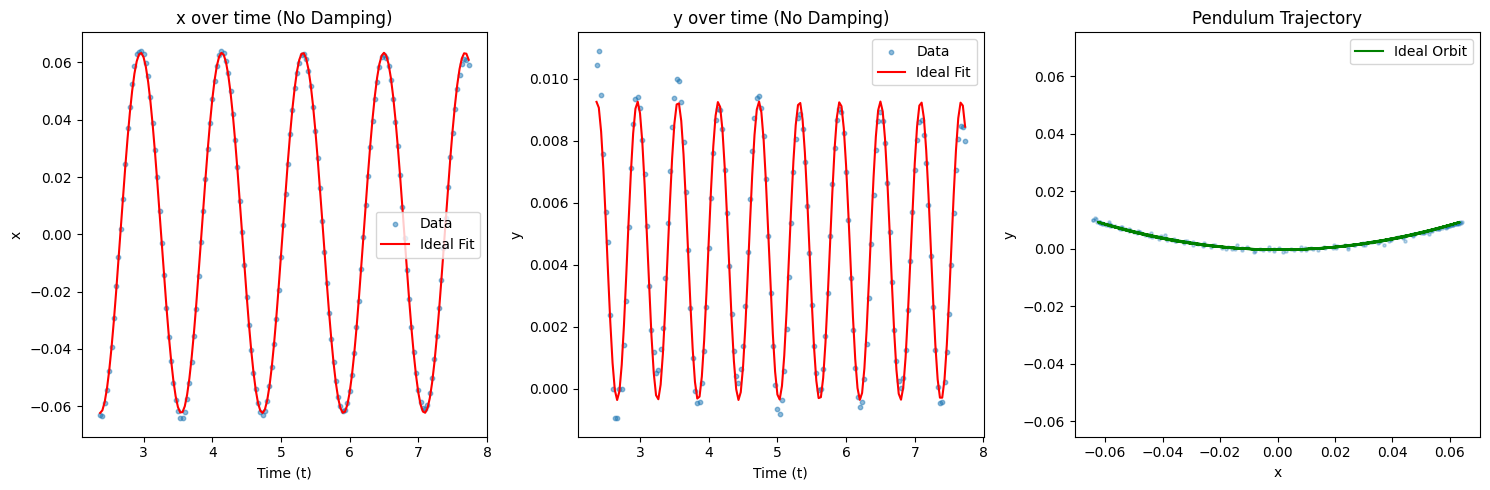

In [ ]:
# 1. 데이터 로드 및 확인
file_path = '/content/txy.txt'
data = pd.read_csv(file_path, sep='\t')
print(data.head())

t = data['t']
x = data['x']
y = data['y']

# 2. 비감쇠 진자 운동 모델 함수 (exp 항 제거)
def ideal_sin_func(t, amp, freq, phase, pos_i):
    """x축 방향: 단순 조화 진동"""
    return amp * np.sin(2 * np.pi * freq * t + phase) + pos_i

def ideal_cos_func(t, amp, freq, phase, pos_i):
    """y축 방향: 단순 조화 진동"""
    return amp * np.cos(2 * np.pi * freq * t + phase) + pos_i

# 3. 피팅 실행
# 초기값(p0)을 명시해주면 피팅 성능이 더 좋아집니다. (예: p0=[0.05, 1.0, 0, 0])
params_x, _ = curve_fit(ideal_sin_func, t, x)

# 1. x에서 구한 진동수를 바탕으로 y의 초기 추측값(p0) 설정
amp_y_guess = (y.max() - y.min()) / 2
freq_y_guess = params_x[1] * 2  # 핵심: y 진동수는 x의 2배
pos_y_guess = y.mean()

# [amp, freq, phase, pos_i] 순서
p0_y = [amp_y_guess, freq_y_guess, 0, pos_y_guess]

# 2. 초기값을 넣어서 재피팅
# bounds를 주어 진동수가 0 이하로 내려가지 않게 강제할 수도 있습니다.
params_y, _ = curve_fit(ideal_cos_func, t, y, p0=p0_y)

# 4. 결과 출력 - x
fitted_x_str = "{:.2f} * sin(2 * pi * {:.2f} * t + {:.2f}) + {:.2f}".format(*params_x)
print("Fitted function (x):", fitted_x_str)
print("Fitted parameters (x) [amp, freq, phase, pos_i]:", params_x)

# 5. 결과 출력 - y
fitted_y_str = "{:.2f} * cos(2 * pi * {:.2f} * t + {:.2f}) + {:.2f}".format(*params_y)
print("Fitted function (y):", fitted_y_str)
print("Fitted parameters (y) [amp, freq, phase, pos_i]:", params_y)

# 6. RMS 계산 (모델과 실제 데이터 사이의 오차 분석용으로 수정)
def calculate_rms_error(data, fitted_data):
    """데이터와 피팅 곡선 사이의 Root Mean Square Error"""
    return np.sqrt(np.mean((data - fitted_data)**2))

rmse_x = calculate_rms_error(x, ideal_sin_func(t, *params_x))
rmse_y = calculate_rms_error(y, ideal_cos_func(t, *params_y))

print(f"RMSE for x: {rmse_x:.5f}")
print(f"RMSE for y: {rmse_y:.5f}")

# 7. 시각화
plt.figure(figsize=(15, 5))

# x over time
plt.subplot(1, 3, 1)
plt.title('x over time (No Damping)')
plt.scatter(t, x, s=10, alpha=0.5, label='Data')
plt.plot(t, ideal_sin_func(t, *params_x), color='red', label='Ideal Fit')
plt.xlabel('Time (t)')
plt.ylabel('x')
plt.legend()

# y over time
plt.subplot(1, 3, 2)
plt.title('y over time (No Damping)')
plt.scatter(t, y, s=10, alpha=0.5, label='Data')
plt.plot(t, ideal_cos_func(t, *params_y), color='red', label='Ideal Fit')
plt.xlabel('Time (t)')
plt.ylabel('y')
plt.legend()

# pendulum motion (Lissajous)
plt.subplot(1, 3, 3)
plt.title('Pendulum Trajectory')
plt.scatter(x, y, s=5, alpha=0.3)
plt.plot(ideal_sin_func(t, *params_x), ideal_cos_func(t, *params_y), color='green', label='Ideal Orbit')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal') # 궤적을 보기 위해 축 비율을 맞춤
plt.legend()

plt.tight_layout()
plt.show()

**5. 진자 운동 분석(공기 저항 o)**

x축과 y축 모두 공기 저항에 의한 감쇠가 존재하므로, 일반적인 공식을 사용하지 않고 감쇠항이 존재하는 그래프로 fitting 해야할 것이다.

계산하면,
𝓍 = 𝒜exp(-γt)sin(𝜔t+ϕ)+x(0) ,
𝓎 = ℬexp(-βt)cos(𝜔t+ψ)+y(0)
으로 계산해볼 수 있다.

          t         x         y
0  2.366667 -0.063033  0.010427
1  2.400000 -0.063507  0.010900
2  2.433333 -0.058768  0.009479
3  2.466667 -0.054502  0.007583
4  2.500000 -0.047867  0.005687
2.4 -0.06350711 0.01090047
Fitted function: -0.01 * exp(-0.03 * t) * cos(2 * pi * 1.70 * t + -9.58) + 0.00
Fitted parameters: [-5.73160553e-03  3.49487801e-02  1.69647095e+00 -9.58495055e+00
  4.45567266e-03]
RMS for y: 0.0004575227453965748


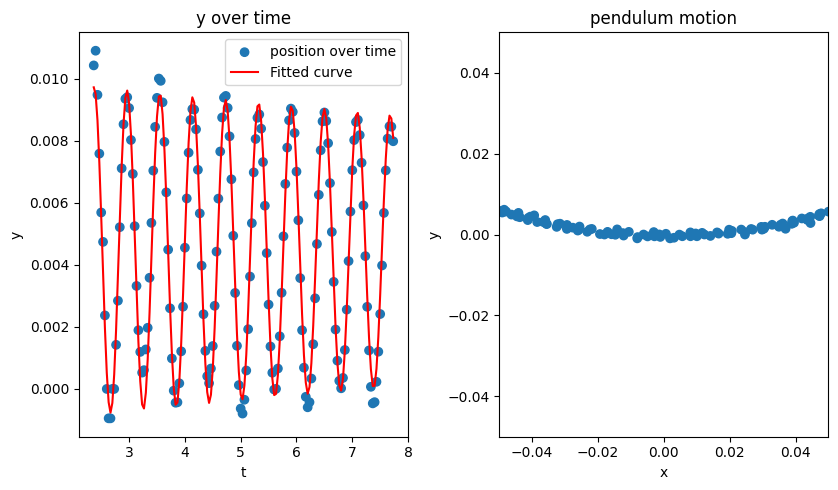

In [ ]:
# Data file path
file_path = '/content/txy.txt'

# Data file load
data = pd.read_csv(file_path, sep='\t')

# Data check
print(data.head())

# Variable assignment
t = data['t']
x = data['x']
y = data['y']

# Variable Check
print(t[1], x[1], y[1])

# Graph Fitting
##def sin_func(t, amp, damp, freq, phase, pos_i):
  #return amp * np.sin(2 * np.pi * freq * t + phase) + pos_i

def dampsin_func(t, amp, damp, freq, phase, pos_i):
  return amp * np.exp(-damp * t) * np.cos(2 * np.pi * freq * t + phase) + pos_i

# Run Fitting
#params_x, covariance = curve_fit(sin_func, t, x)
params_y, covariance = curve_fit(dampsin_func, t, y, method='dogbox')

# Print Fitted function - x
#fitted_function_str = "{:.2f} * exp(-{:.2f} * t) * sin(2 * pi * {:.2f} * t + {:.2f}) + {:.2f}".format(params_x[0], params_x[1], params_x[2], params_x[3], params_x[4])
#print("Fitted function:", fitted_function_str)
#print("Fitted parameters:", params_x)

# Print Fitted function - y
fitted_function_str = "{:.2f} * exp(-{:.2f} * t) * cos(2 * pi * {:.2f} * t + {:.2f}) + {:.2f}".format(params_y[0], params_y[1], params_y[2], params_y[3], params_y[4])
print("Fitted function:", fitted_function_str)
print("Fitted parameters:", params_y)

# 실제 데이터와 모델 예측값 사이의 오차를 구하도록 수정
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

#rmse_x = calculate_rmse(x, sin_func(t, *params_x))
rmse_y = calculate_rmse(y, dampsin_func(t, *params_y))

#print("RMS for x:", rmse_x)
print("RMS for y:", rmse_y)

# Plotting
plt.figure(figsize=(12,5))

## 1. x over time
#plt.subplot(1,3,1)
#plt.title('x over time')
#plt.scatter(t, x, marker='o', linestyle='', label='position over time')
#plt.plot(t, sin_func(t, *params_x), color='red', label='Fitted curve')
#plt.xlabel('t')
#plt.ylabel('x')
#plt.legend(loc='upper right')

## 2. y over time
plt.subplot(1,3,2)
plt.title('y over time')
plt.scatter(t, y, marker='o', linestyle='', label='position over time')
plt.plot(t, dampsin_func(t, *params_y), color='red', label='Fitted curve')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()

## 3. pendulum motion
plt.subplot(1,3,3)
plt.title('pendulum motion')
plt.xlim(-0.05,0.05)
plt.ylim(-0.05,0.05)
plt.scatter(x, y, marker='o', linestyle='', label="xy")
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

**6. auto fitting**


--- Anaylsis for x(t) ---
Model: Linear       | AIC: -1625.03
Model: Quadratic    | AIC: -1623.03
Model: Sine         | AIC: 541.41
▶ Winner: Linear | Formula: x(t) = 10.0000 * t + 0.0000

--- Anaylsis for y(t) ---
Model: Linear       | AIC: 450.50
Model: Quadratic    | AIC: -1552.99
Model: Sine         | AIC: 492.73
Model: Damped sine  | AIC: -1317.36
▶ Winner: Quadratic | Formula: y(t) = -4.9050 * t^2 + 19.9998 * t + 0.0002


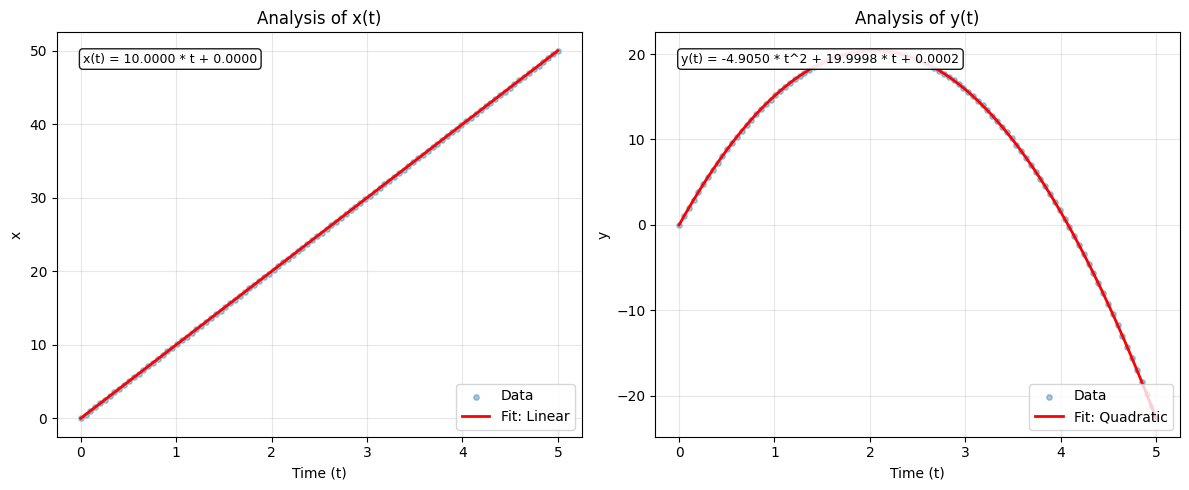

In [ ]:
file_path = '/content/trm.txt'

#1. model 설정
def linear(t, a, b):
  return a * t + b
def get_linear_str(p, var):
  return f"{var}(t) = {p[0]:.4f} * t + {p[1]:.4f}"

def quad(t, a, b, c):
  return a * t**2 + b * t + c
def get_quad_str(p, var):
  return f"{var}(t) = {p[0]:.4f} * t^2 + {p[1]:.4f} * t + {p[2]:.4f}"

def sine(t, amp, freq, phase, offset):
  return amp * np.sin(2 * np.pi * freq * t + phase) + offset
def get_sine_str(p, var):
  return f"{var}(t) = {p[0]:.4f} * sin(2pi * {p[1]:.4f} * t + {p[2]:.4f}) + {p[3]:.4f}"

def damped_sine(t, amp, damp, freq, phase, offset):
  return amp * np.exp(-damp * t) * np.sin(2 * np.pi * freq * t + phase) + offset
def get_damped_sine_str(p, var):
  return f"{var}(t) = {p[0]:.4f} * exp(-{p[1]:.4f} * t ) * sin(2pi * {p[2]:.4f} * t + {p[3]:.4f}) + {p[4]:.4f}"

model_inventory = {
    "Linear": (linear, get_linear_str),
    "Quadratic": (quad, get_quad_str),
    "Sine": (sine, get_sine_str),
    "Damped sine": (damped_sine, get_damped_sine_str)
}

#2. AIC 기반 auto fitting 로직
def auto_fit_with_logic(t, y_data, var_name='x', x_freq=None):
  best_aic = np.inf
  best_model_name = None
  best_params = None
  n = len(y_data)

  print(f"\n--- Anaylsis for {var_name}(t) ---")

  for name, (func, formula_func) in model_inventory.items():
        try:
            p0 = None
            if "Sine" in name:
                amp_g = (np.max(y_data) - np.min(y_data)) / 2
                off_g = np.mean(y_data)
                freq_g = x_freq * 2 if (var_name == 'y' and x_freq) else 1.0

                if name == "Sine": p0 = [amp_g, freq_g, 0, off_g]
                else: p0 = [amp_g, 0.01, freq_g, 0, off_g]

            params, _ = curve_fit(func, t, y_data, p0=p0, maxfev=20000)

            y_pred = func(t, *params)
            mse = np.mean((y_data - y_pred)**2)
            if mse <= 0: continue

            # AIC 계산 (벌점 항 포함)
            aic = n * np.log(mse) + 2 * len(params)
            print(f"Model: {name:12} | AIC: {aic:.2f}")

            if aic < best_aic:
                best_aic = aic
                best_model_name = name
                best_params = params
        except:
            continue

  if best_model_name:
      formula = model_inventory[best_model_name][1](best_params, var_name)
      print(f"▶ Winner: {best_model_name} | Formula: {formula}")
      return best_model_name, best_params, formula
  return None, None, "Fitting Failed"

def run_analysis(file_path):
    try:
        df = pd.read_csv(file_path, sep=r'\s+')
    except:
        print("Check file path or format."); return

    t_arr = df['t'].values
    targets = [c for c in ['x', 'y'] if c in df.columns]

    fig, axes = plt.subplots(1, len(targets), figsize=(6*len(targets), 5), squeeze=False)
    x_freq_found = None

    for i, var in enumerate(targets):
        y_arr = df[var].values
        ax = axes[0, i]

        # 피팅 수행 (x_freq 전달)
        m_name, params, formula = auto_fit_with_logic(t_arr, y_arr, var, x_freq_found)

        # x의 진동수 저장 (y 피팅 가이드용)
        if var == 'x' and m_name in ["Sine", "Damped Sine"]:
            x_freq_found = params[1] if m_name == "Sine" else params[2]

        # 시각화
        ax.scatter(t_arr, y_arr, s=15, alpha=0.4, label='Data')
        if m_name:
            t_fine = np.linspace(t_arr.min(), t_arr.max(), 1000)
            y_fit = model_inventory[m_name][0](t_fine, *params)
            ax.plot(t_fine, y_fit, 'r-', lw=2, label=f'Fit: {m_name}')
            ax.text(0.05, 0.95, formula, transform=ax.transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        ax.set_title(f'Analysis of {var}(t)')
        ax.set_xlabel('Time (t)'); ax.set_ylabel(var)
        ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

# 실행
run_analysis(file_path)